In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [5]:

# Read image in grayscale
image = cv2.imread("image.jpeg", cv2.IMREAD_GRAYSCALE)
height, width = image.shape

In [6]:
# Create output images
laplacian = np.zeros_like(image)
sobel_x = np.zeros_like(image)
sobel_y = np.zeros_like(image)
gradient = np.zeros_like(image)

In [7]:
# =================================
# Laplacian Mask
# =================================

lap_mask = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
])


In [8]:
# =================================
# Sobel Gradient Masks
# =================================

sobel_x_mask = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y_mask = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

In [9]:
# =================================
# Apply Masks
# =================================

for i in range(1, height - 1):
    for j in range(1, width - 1):

        # 3x3 neighborhood
        region = image[i-1:i+2, j-1:j+2]

        # Laplacian
        lap_value = np.sum(region * lap_mask)
        laplacian[i, j] = np.clip(abs(lap_value), 0, 255)

        # Sobel X
        x_value = np.sum(region * sobel_x_mask)
        sobel_x[i, j] = np.clip(abs(x_value), 0, 255)

        # Sobel Y
        y_value = np.sum(region * sobel_y_mask)
        sobel_y[i, j] = np.clip(abs(y_value), 0, 255)

        # Gradient
        gradient_value = abs(x_value) + abs(y_value)
        gradient[i, j] = np.clip(gradient_value, 0, 255)

In [10]:
# =================================
# Laplacian Sharpened Image
# =================================

sharpened = image.astype(int) - laplacian.astype(int)
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

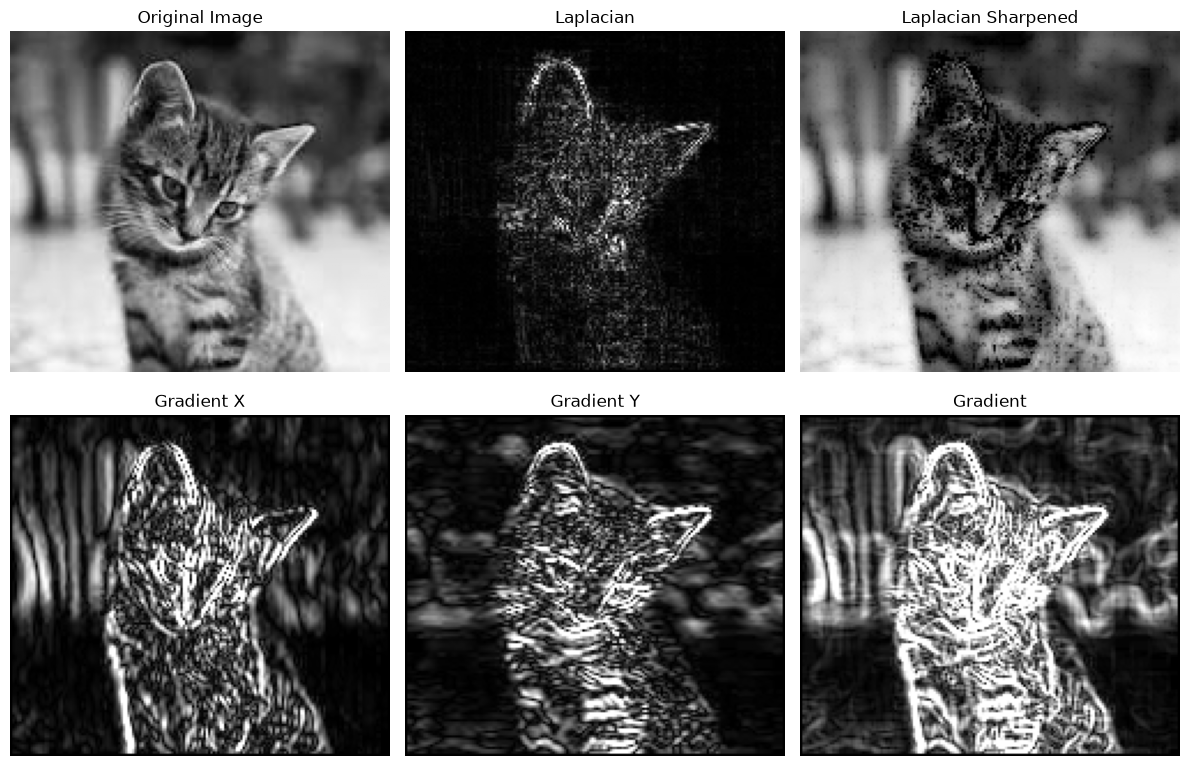

In [11]:
# =================================
# Display Results
# =================================

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(sharpened, cmap="gray")
plt.title("Laplacian Sharpened")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel_x, cmap="gray")
plt.title("Gradient X")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sobel_y, cmap="gray")
plt.title("Gradient Y")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(gradient, cmap="gray")
plt.title("Gradient")
plt.axis("off")

plt.tight_layout()
plt.show()